# Talmud-Portfolio -- does a 2,000-year-old allocation beat 60/40?
### 1/3 real estate (VNQ) + 1/3 stocks (SPY) + 1/3 bonds (BND), tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![vs_60/40%3F: No_Edge](https://img.shields.io/badge/vs_60/40%3F-No__Edge-8b949e?style=flat-square)

The Babylonian Talmud (~3rd century CE) says: *'A man should always divide his money into three parts -- a third in land, a third in business, a third in reserve.'* Put into modern ETFs that's 1/3 VNQ (real estate), 1/3 SPY (stocks), 1/3 BND (bonds). Finance Twitter has declared it a timeless diversification insight. We tested it.

> **This is the plain-language layer.** For t-stats, HAC inference, and the crash tables, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from talmud_portfolio import data, strategy as st

STUDY_CACHE = os.path.join(os.path.abspath(".."), "_cache", "talmud_prices.parquet")
SHARED_PANEL = os.path.join(os.path.abspath("../../.."), "_cache", "cross_asset_etfs.parquet")

def _have_cache():
    return os.path.exists(STUDY_CACHE) or os.path.exists(SHARED_PANEL)

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=4825, n_years=19.1,
    tal_cagr=6.9, tal_sharpe=0.31, tal_vol=14.6, tal_mdd=-44.0, tal_worst=-22.3,
    s60_cagr=8.1, s60_sharpe=0.46, s60_vol=11.5, s60_mdd=-33.8, s60_worst=-19.3,
    spy_cagr=10.9, spy_sharpe=0.45, spy_vol=19.7, spy_mdd=-55.2, spy_worst=-36.8,
    vnq_cagr=8.3, vnq_sharpe=0.32, vnq_mdd=-62.6,
    t_vs_6040=-1.26, t_vs_spy=-3.03, t_vs_vnq=-1.95,
    gfc_spy=-55.2, gfc_vnq=-69.3, gfc_bnd=7.5,
    covid_spy=-33.7, covid_vnq=-41.5, covid_bnd=-1.4,
    rate22_spy=-24.5, rate22_vnq=-31.9, rate22_bnd=-14.5,
)


real price cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the Talmud beat 60/40? | **No.** Talmud CAGR **6.9%** vs 60/40 **8.1%**; Sharpe **0.31** vs **0.46**. |
| Does it reduce drawdown vs 60/40? | **No.** Talmud max DD **-44.0%** vs 60/40 **-33.8%** -- *deeper* because VNQ crashes with stocks. |
| Does the REIT 'land' leg hedge crashes? | **No.** In the GFC, VNQ fell **-69.3%** vs SPY **-55.2%**. REITs amplify. Bonds hedge. |
| Is it tradable? | **Yes, but why?** Annual rebalance, liquid ETFs. But 60/40 beats it on every metric. |

> The ancient wisdom is not wrong -- diversify -- but the *specific implementation* replacing half the bond hedge with REITs turns out to be the worst possible swap.

## 1 . The claim

> *'A third in land, a third in business, a third in reserve.'*
> -- Babylonian Talmud, Bava Metzia 42a (~3rd century CE)

The modern finance version: put one-third each in real estate (VNQ), stocks (SPY), and bonds (BND). Rebalance annually. The theory: three asset classes that respond differently to economic conditions (growth, inflation, safe-haven) diversify your risk without sacrificing too much return -- like a 2,000-year-old risk-parity idea.

We test it against the natural competitor: the 60/40 portfolio (SPY/BND), which has been the standard 'diversified' benchmark for decades.

## 2 . So what?

If the Talmud allocation really is superior, it would mean: (a) the ancient writers anticipated modern diversification theory, and (b) REITs add genuine diversification value that a simple stock-bond split misses. If it's false, thousands of people are swapping a perfectly good bond hedge for an asset class that *feels* different but crashes with stocks when it matters most.

## 3 . How would we know?

One honest comparison: run all four portfolios over the same 19 years (2007-2026, the earliest available window for BND) and ask whether the Talmud blend delivers better risk-adjusted returns than the alternatives.

The key test is **Sharpe ratio** (return per unit of volatility) and **max drawdown** (the worst peak-to-trough loss), since the Talmud's stated purpose is to survive any economic environment. We also look at crash behaviour: does VNQ actually hedge during equity bear markets, as 'land' would be supposed to?

## 4 . The teardown

### The equity curves: Talmud trails 60/40 the entire way

Loaded 4825 days (2007-04-10 -> 2026-06-11)


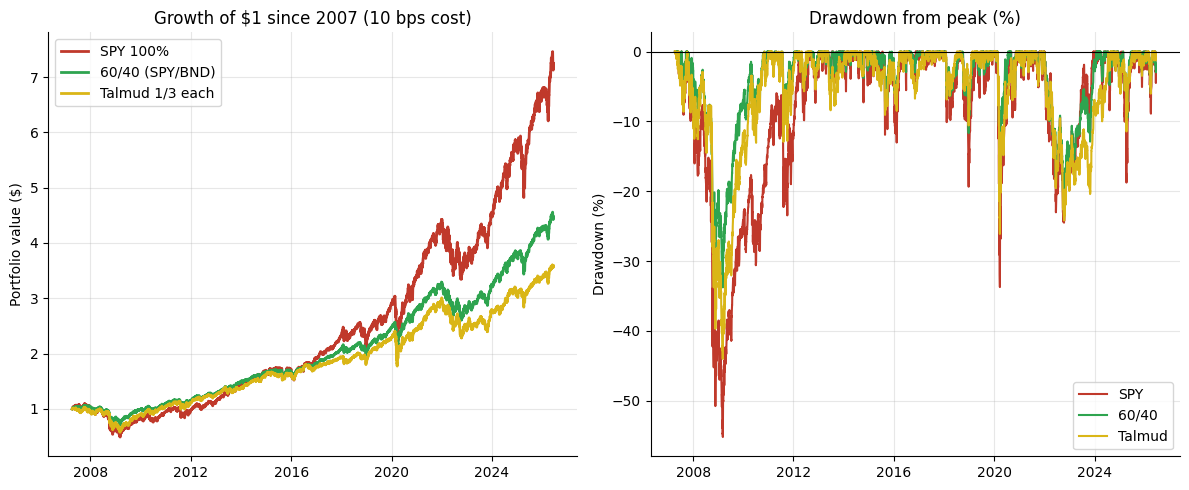

In [2]:
if HAVE_REAL:
    prices = data.load_real()
    ret = st.to_returns(prices)
    rf = ret["BND"]
    tal   = st.talmud_portfolio(ret, cost_bps=10.0)
    s6040 = st.sixty_forty(ret, cost_bps=10.0)
    spy   = st.spy_only(ret)
    vnq50 = st.spy_vnq_50_50(ret, cost_bps=10.0)
    s_tal  = st.portfolio_stats(tal, rf=rf)
    s_6040 = st.portfolio_stats(s6040, rf=rf)
    s_spy  = st.portfolio_stats(spy, rf=rf)
    s_vnq  = st.portfolio_stats(vnq50, rf=rf)
    print(f"Loaded {len(prices)} days ({prices.index[0].date()} -> {prices.index[-1].date()})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if HAVE_REAL:
    equity_tal  = (1 + tal).cumprod()
    equity_6040 = (1 + s6040).cumprod()
    equity_spy  = (1 + spy).cumprod()
    axes[0].plot(equity_spy.index,  equity_spy.values,  c=RED,   lw=2,   label="SPY 100%")
    axes[0].plot(equity_6040.index, equity_6040.values, c=GREEN, lw=2,   label="60/40 (SPY/BND)")
    axes[0].plot(equity_tal.index,  equity_tal.values,  c=AMBER, lw=2,   label="Talmud 1/3 each")
    axes[0].set_title("Growth of $1 since 2007 (10 bps cost)")
    axes[0].set_ylabel("Portfolio value ($)")
    axes[0].legend()
    # Drawdown
    for eq, c, lbl in [(equity_spy,RED,"SPY"),(equity_6040,GREEN,"60/40"),(equity_tal,AMBER,"Talmud")]:
        dd = eq / eq.cummax() - 1
        axes[1].plot(eq.index, dd.values * 100, c=c, lw=1.5, label=lbl)
    axes[1].axhline(0, c="k", lw=0.8)
    axes[1].set_title("Drawdown from peak (%)")
    axes[1].set_ylabel("Drawdown (%)")
    axes[1].legend()
else:
    axes[0].text(0.5, 0.5, f"No cache. Key: Talmud CAGR {R['tal_cagr']}% | 60/40 {R['s60_cagr']}% | SPY {R['spy_cagr']}%",
                 ha="center", va="center", transform=axes[0].transAxes, fontsize=10, wrap=True)
    axes[0].set_title("Equity curves (cache absent)")
    axes[1].text(0.5, 0.5, f"Talmud MaxDD {R['tal_mdd']}% | 60/40 {R['s60_mdd']}% | SPY {R['spy_mdd']}%",
                 ha="center", va="center", transform=axes[1].transAxes, fontsize=10)
    axes[1].set_title("Drawdowns (cache absent)")

plt.tight_layout()
plt.show()


The Talmud portfolio trailed 60/40 by **1.2 pp/yr** over 19 years with a *deeper* max drawdown. This is the opposite of what the 'defensive three-way diversification' story predicts.

### The critical failure: VNQ doesn't hedge -- it amplifies

The Talmud's 'land' leg is supposed to be a *reserve* against calamity. Here is what happened to VNQ in every major equity crash:

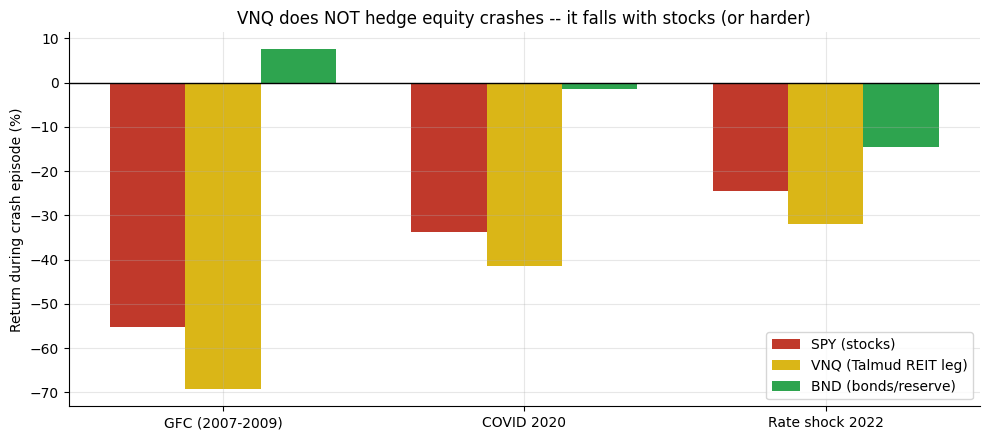

BND (green) provides real hedging. VNQ (amber) amplifies. The Talmud swaps the wrong asset.


In [3]:

crashes = [
    ("GFC (2007-2009)", R['gfc_spy'], R['gfc_vnq'], R['gfc_bnd']),
    ("COVID 2020",      R['covid_spy'], R['covid_vnq'], R['covid_bnd']),
    ("Rate shock 2022", R['rate22_spy'], R['rate22_vnq'], R['rate22_bnd']),
]
fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(crashes))
w = 0.25
labels = [c[0] for c in crashes]
ax.bar([i-w for i in x], [c[1] for c in crashes], width=w, color=RED,   label="SPY (stocks)")
ax.bar([i   for i in x], [c[2] for c in crashes], width=w, color=AMBER, label="VNQ (Talmud REIT leg)")
ax.bar([i+w for i in x], [c[3] for c in crashes], width=w, color=GREEN, label="BND (bonds/reserve)")
ax.axhline(0, c="k", lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("Return during crash episode (%)")
ax.set_title("VNQ does NOT hedge equity crashes -- it falls with stocks (or harder)")
ax.legend()
plt.tight_layout()
plt.show()
print("BND (green) provides real hedging. VNQ (amber) amplifies. The Talmud swaps the wrong asset.")


In the GFC, VNQ fell **-69%** while SPY fell **-55%** -- REITs were *levered* equity in the worst crash. Bonds (BND) were the only genuine hedge, rising **+7.5%**. The Talmud's 'land' leg is a REIT index, which behaves like equity in crises, not like the physical property the ancient text had in mind.

By replacing 40% of the bond hedge with VNQ, the Talmud blend removes the one thing that actually works in a crash and adds more of the thing that crashes.

## 5 . The verdict

- **Signal -- Weak.** Talmud Sharpe **0.31** (positive, real) but below 60/40's **0.46**; not statistically better (HAC t = -1.26).
- **Tradability -- Fragile.** Technically tradable (annual rebalance, liquid ETFs), but dominated by 60/40 on every metric: lower CAGR, lower Sharpe, deeper max drawdown.
- **vs 60/40? -- No Edge.** The REIT leg fails its diversification mission in every major crash. The 2,000-year-old insight ('diversify across land, business, reserve') is sound -- the modern ETF implementation is not.

## 6 . Could you actually trade it?

Yes -- but you'd be better off with 60/40. The Talmud portfolio is operationally easy (annual rebalance, three liquid ETFs, low turnover) and cheap to run. The problem is not the trading; it's the allocation itself.

In [4]:

rows = [
    ("Talmud 1/3-1/3-1/3", R['tal_cagr'], R['tal_sharpe'], R['tal_mdd'], R['tal_vol']),
    ("60/40 (SPY/BND)",      R['s60_cagr'], R['s60_sharpe'], R['s60_mdd'], R['s60_vol']),
    ("SPY 100%",             R['spy_cagr'], R['spy_sharpe'], R['spy_mdd'], R['spy_vol']),
]
if HAVE_REAL:
    rows = [
        ("Talmud 1/3-1/3-1/3", s_tal['cagr']*100,  s_tal['sharpe'],  s_tal['max_dd']*100,  s_tal['vol']*100),
        ("60/40 (SPY/BND)",      s_6040['cagr']*100, s_6040['sharpe'], s_6040['max_dd']*100, s_6040['vol']*100),
        ("SPY 100%",             s_spy['cagr']*100,  s_spy['sharpe'],  s_spy['max_dd']*100,  s_spy['vol']*100),
    ]
tbl = pd.DataFrame(rows, columns=["Portfolio","CAGR %","Sharpe","Max DD %","Vol %"])
print(tbl.to_string(index=False))


         Portfolio    CAGR %   Sharpe   Max DD %     Vol %
Talmud 1/3-1/3-1/3  6.902473 0.310212 -43.990298 14.618457
   60/40 (SPY/BND)  8.146817 0.455239 -33.757901 11.515084
          SPY 100% 10.900764 0.448127 -55.189452 19.727235


## 7 . Going further

- **What if you want three legs AND a better hedge?** The [Permanent Portfolio (Study 144)](../../144-permanent-portfolio/) uses 25% each in stocks, long Treasuries, gold, and cash. Gold -- unlike VNQ -- actually hedges equity crises (it rose in the GFC). Sharpe is better than the Talmud.
- **Pure risk parity?** [Study 68 -- All-Weather](../../68-all-weather/) tests the Bridgewater risk-parity approach, which weights by inverse volatility and goes heavy on bonds -- the lesson from VNQ is that the bond weight matters most.
- **Is equal-weight ever good?** [Study 171 -- Naive-1-Over-N](../../171-naive-1-over-n/) shows that 1/N equal-weight beats Markowitz optimisers on sector ETFs -- the Talmud's 1/3 rule is optimal among naive allocators, just on the wrong set of assets.

*Think the REIT leg adds value in a different window or with a different REIT index? Fork this, test it, and show the Sharpe improvement. That's the bar.*